In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.misc.sort import selection


EDA


In [20]:
df=pd.read_csv("../dataset/Housing.csv")
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


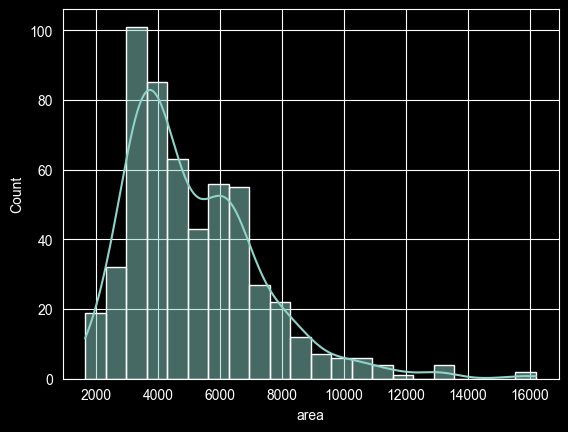

In [21]:
sns.histplot(df['area'],kde=True)
plt.savefig("Hosing_histogram.png")
plt.show()

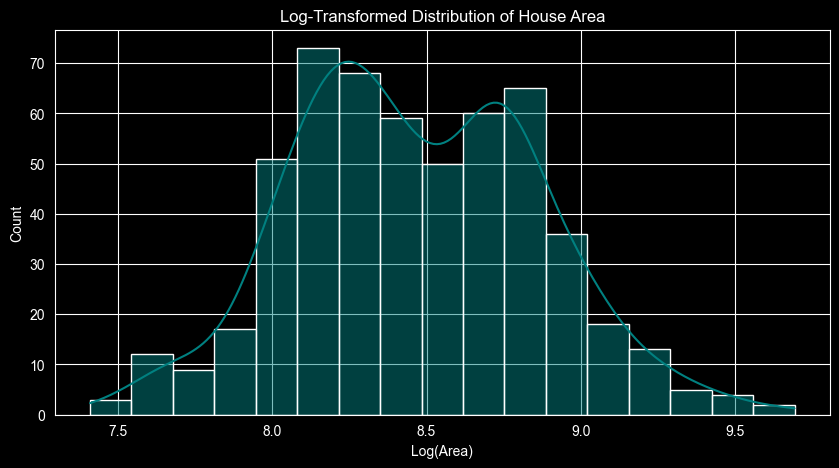

In [27]:
df["area"].head()
df['log_area'] = np.log1p(df['area'])

# 2. Plot to see the result
plt.figure(figsize=(10, 5))
sns.histplot(df['log_area'], kde=True, color='teal')
plt.title("Log-Transformed Distribution of House Area")
plt.xlabel("Log(Area)")
plt.ylabel("Count")
plt.savefig("Housing_log_histogram.png")
plt.show()


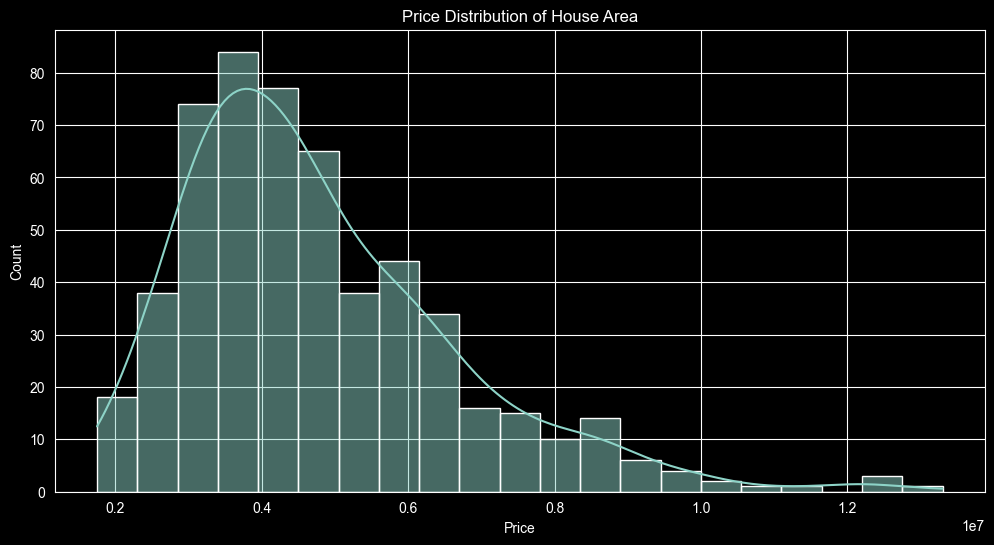

In [28]:
plt.figure(figsize=(12, 6))
sns.histplot(df["price"],kde=True)
plt.title("Price Distribution of House Area")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("price_histogarm.png")
plt.show()


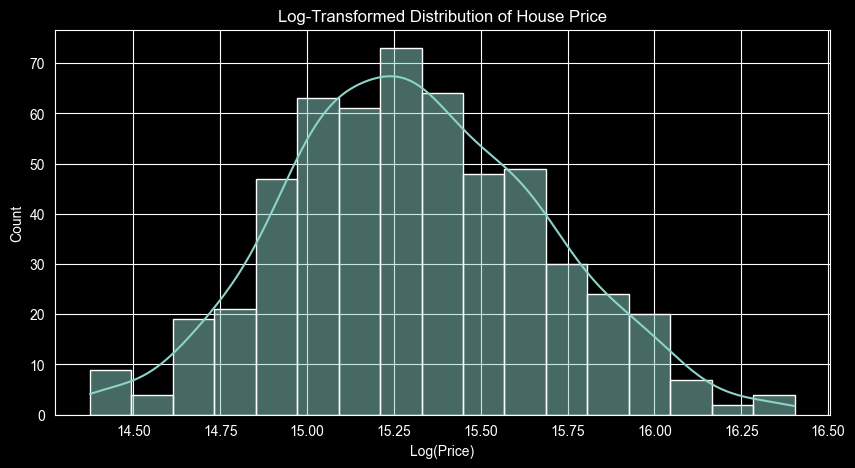

In [29]:
df["log_price"] = np.log1p(df['price'])
plt.figure(figsize=(10, 5))
sns.histplot(df['log_price'], kde=True)
plt.title("Log-Transformed Distribution of House Price")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.savefig("log_price_histogarm.png")
plt.show()


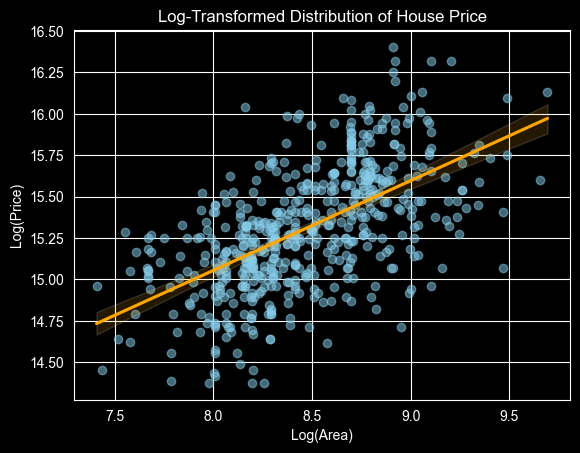

In [32]:
sns.regplot(x=df['log_area'], y=df['log_price'],
            scatter_kws={'alpha':0.5, 'color':'skyblue'}, # Transparent dots help see density
            line_kws={'color':'orange'}) #
plt.title("Log-Transformed Distribution of House Price")
plt.ylabel("Log(Price)")
plt.xlabel("Log(Area)")
plt.savefig("log_scatterplot.png")
plt.show()


In [34]:
df.isnull().sum()
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  \
0              no             yes        2      yes        furnished   
1              no             yes        3       no        furnished   
2              no              no        2      yes   semi-furnished   
3              no             yes        3      yes        furnished   
4              no             yes        2       no        furnished   

   log_area  log_price  
0  8.912069  16.403275  
1  9.100637  16.321037  
2  9.206433  16.3

Label Encoding

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
text_cols=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]
for col in text_cols:
    df[col] = le.fit_transform(df[col])

In [37]:
print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  log_area  log_price  
0                 0  8.912069  16.403275  
1                 0  9.100637  16.321037  
2                 1  9.206433

Correlation


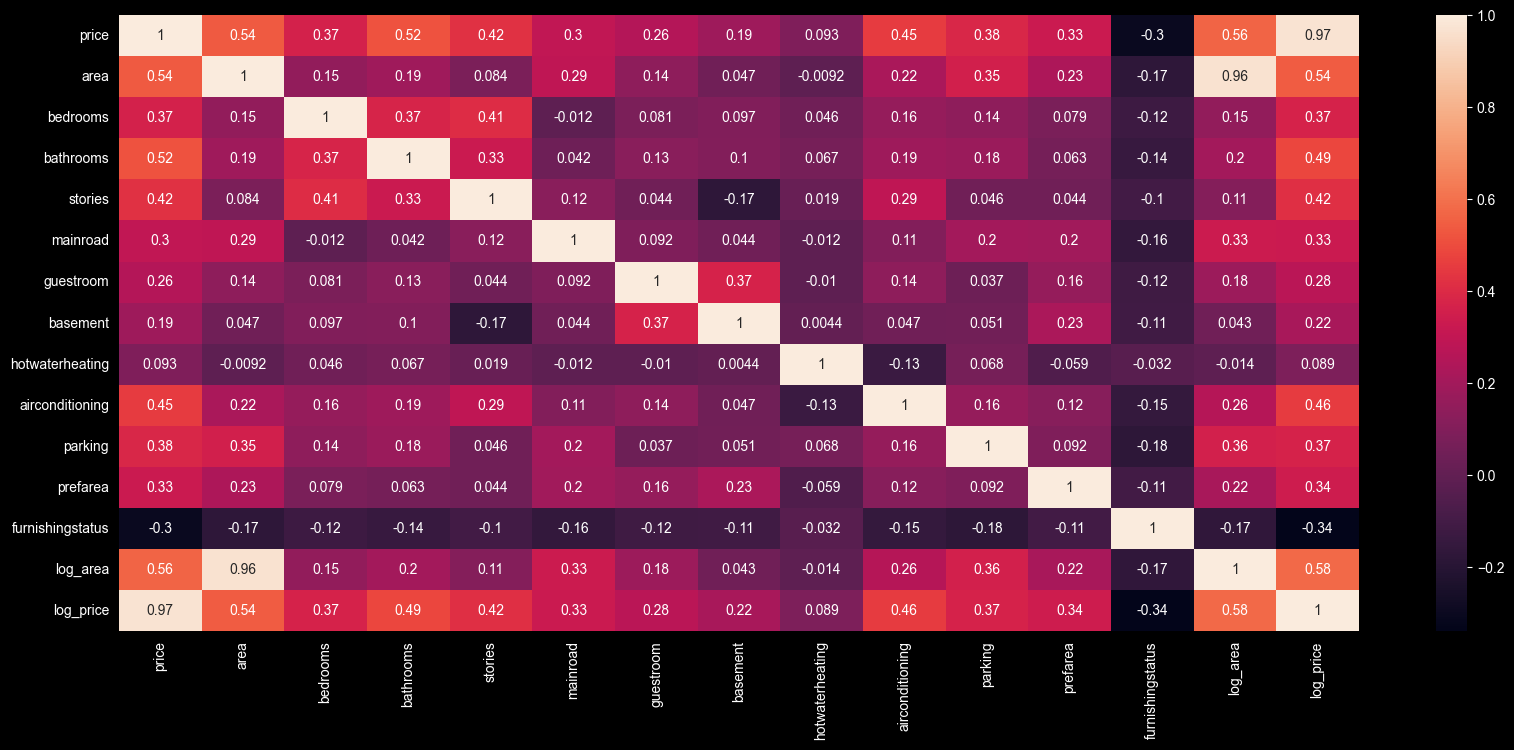

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(20, 8))
sns.heatmap(df.corr(),annot=True)
plt.show()

plt.savefig("correlation_matrix.png")


Feature selection

In [42]:
X=df.drop(["price","log_price","area"],axis=1)
y=df["log_price"]

Train test split

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


Model training

In [44]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)


Metrices

In [48]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred)
print("Mean squared error",mse)
print(f"R2 Score: {r2_score(y_test, y_pred)}")


Mean squared error 0.06498371983586189
R2 Score: 0.6634513584593629


Feature Importance

In [49]:
importance=pd.DataFrame({"feature":X.columns,"Coefficient":regressor.coef_,"Intercept":regressor.intercept_})
print("Importance")
print(importance)

Importance
             feature  Coefficient  Intercept
0           bedrooms     0.021489   12.17917
1          bathrooms     0.186498   12.17917
2            stories     0.081924   12.17917
3           mainroad     0.087825   12.17917
4          guestroom     0.036971   12.17917
5           basement     0.106158   12.17917
6    hotwaterheating     0.133957   12.17917
7    airconditioning     0.141643   12.17917
8            parking     0.033566   12.17917
9           prefarea     0.133117   12.17917
10  furnishingstatus    -0.059714   12.17917
11          log_area     0.297055   12.17917


Actual vs Predicted

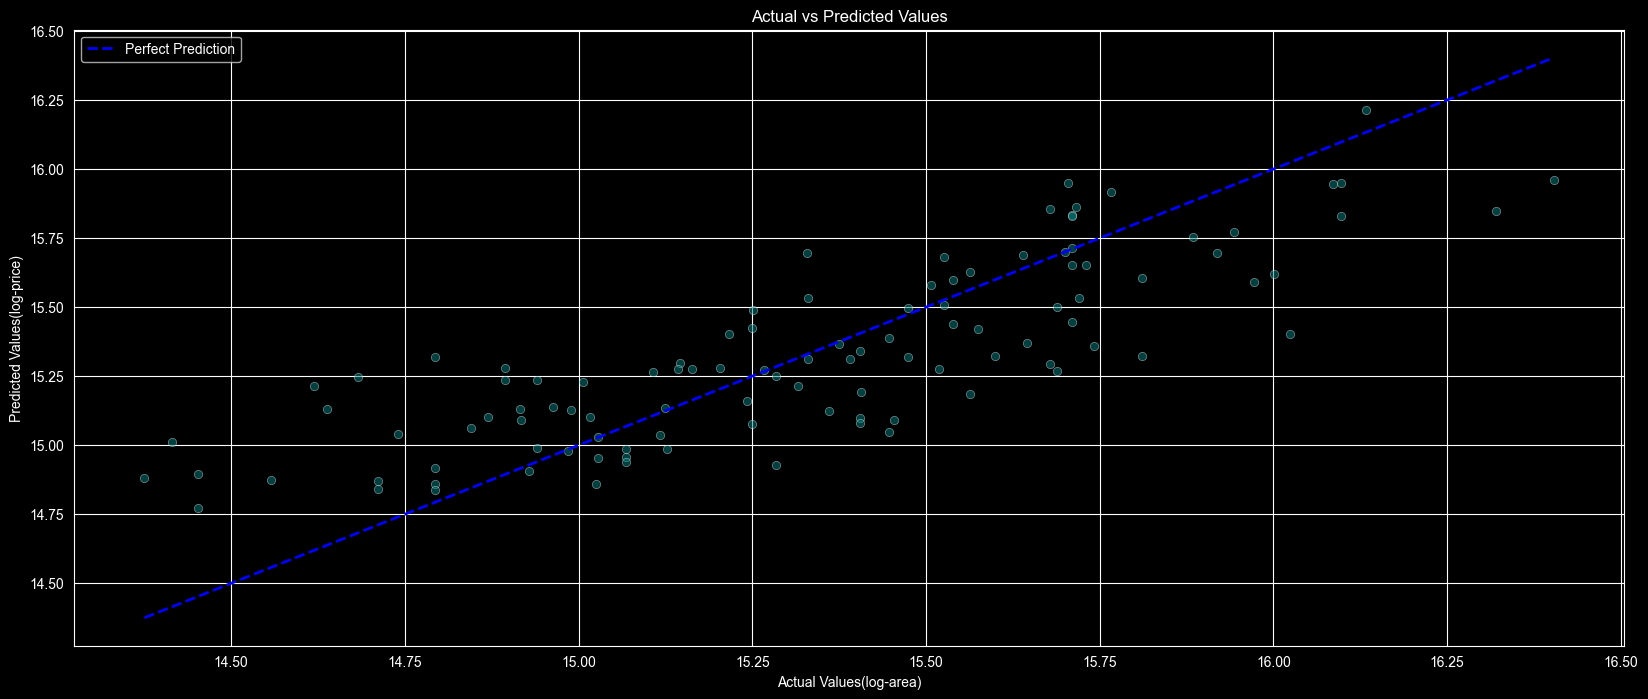

<Figure size 640x480 with 0 Axes>

In [51]:

plt.figure(figsize=(20, 8))
plt.title("Actual vs Predicted Values")
sns.scatterplot(x=y_test,y=y_pred,alpha=0.5,color='teal',edgecolor='w')
linecords=np.linspace(y_test.min(),y_test.max(),100)
plt.plot(linecords,linecords,color='blue',linestyle='--',linewidth=2,label='Perfect Prediction')
plt.legend(loc='best')
plt.xlabel("Actual Values(log-area)")
plt.ylabel("Predicted Values(log-price)")
plt.show()
plt.savefig("./assets/actual_vs_predicted.png")